# **Notebook 13 – Model Evaluation – Regression**

In [1]:
# Load Dataset 
import pandas as pd 
df = pd.read_csv("student_performance.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Study_Hours            500 non-null    float64
 1   Attendance             500 non-null    float64
 2   Previous_Score         500 non-null    float64
 3   Sleep_Hours            500 non-null    float64
 4   Assignments_Completed  500 non-null    int64  
 5   Final_Score            500 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


## **1. Mean Absolute Error (MAE)**

**Understand the Concept**

- MAE measures the average error between actual and predicted values.
- It shows how far the predictions are from the actual values.
- Lower MAE means better predictions.

**Formula**

MAE = Σ |Actual - Predicted| / Number of values

**Example**

- Actual score is 80 and predicted score is 75.
- The error is 5.

**When to Use**

- Use MAE when you want an easy-to-understand error value.

**Advantages**

- Easy to understand.
- Less affected by large errors than MSE.

**Limitations**

- Does not give more importance to large errors.

In [2]:
from sklearn.metrics import mean_absolute_error

actual = [80, 70, 90, 60, 75]
predicted = [75, 72, 85, 65, 70]

mae = mean_absolute_error(actual, predicted)

print("MAE:", mae)

MAE: 4.4


## **2. Mean Squared Error (MSE)**

**Understand the Concept**

- MSE measures the average squared error between actual and predicted values.
- Large errors have more effect because the errors are squared.
- Lower MSE means better predictions.

**Formula**

MSE = Σ(Actual - Predicted)² / Number of values

**Example**

- Actual score is 80 and predicted score is 75.
- The squared error is 25.

**When to Use**

- Use MSE when large errors should have more importance.

**Advantages**

- Gives more importance to large errors.
- Useful for comparing regression models.

**Limitations**

- Sensitive to large errors.
- The result is in squared units.

In [3]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(actual, predicted)
print("MSE:", mse)

MSE: 20.8


## **3. Root Mean Squared Error (RMSE)**

**Understand the Concept**

- RMSE measures the average prediction error.
- It gives more importance to large errors.
- Lower RMSE means better predictions.

**Formula**

RMSE = √MSE

**Example**

- If MSE is 25, the RMSE is 5.
- RMSE is in the same unit as the target.

**When to Use**

- Use RMSE when large errors are important.

**Advantages**

- Easy to understand.
- Shows large errors clearly.
- Same unit as the target.

**Limitations**

- Sensitive to large errors.

In [4]:
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 4.560701700396552


**Explanation**

- RMSE is the square root of MSE.
- Large errors have more effect on RMSE.
- Lower RMSE means better predictions.

## **4. R² Score**

**Understand the Concept**

- R² Score shows how well the model explains the target values.
- It compares the model predictions with the average value.
- Higher R² means the model fits the data better.

**Formula**

R² = 1 - (SSᵣₑₛ / SSₜₒₜ)

- SSᵣₑₛ → Sum of squared prediction errors.
- SSₜₒₜ → Total sum of squared differences.

**Example**

- R² = 0.80 means the model explains about 80% of the variation.
- R² = 1 means perfect predictions.

**When to Use**

- Use R² to understand how well a regression model fits the data.

**Advantages**

- Easy to compare regression models.
- Shows the overall model fit.

**Limitations**

- A high R² does not always mean a good model.
- R² can increase when more features are added.

In [5]:
from sklearn.metrics import r2_score

r2 = r2_score(actual, predicted)
print("R² Score:", r2)

R² Score: 0.792


**Explanation**

- R² shows how well the model fits the data.
- Higher R² means better fit.
- R² = 1 means perfect prediction.

## **5. Adjusted R²**

**Understand the Concept**

- Adjusted R² measures model fit while considering the number of features.
- It gives a lower score when unnecessary features are added.
- Higher Adjusted R² means a better model fit.

**Formula**

Adjusted R² = 1 - [(1 - R²)(n - 1) / (n - p - 1)]

- n → Number of data points.
- p → Number of features.
- R² → R² Score.

**Example**

- R² may increase when a new feature is added.
- Adjusted R² increases only when the new feature is useful.

**When to Use**

- Use Adjusted R² when comparing models with different numbers of features.

**Advantages**

- Considers the number of features.
- Helps identify unnecessary features.

**Limitations**

- More difficult to understand than R².
- It does not show prediction error directly.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df[["Study_Hours","Attendance","Previous_Score","Sleep_Hours","Assignments_Completed"]]
y = df["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print("R² Score:", r2)
print("Adjusted R²:", adjusted_r2)

R² Score: 0.7517928835611051
Adjusted R²: 0.7385903773675468


## **6. Residual Analysis**

**Understand the Concept**

- Residual is the difference between actual and predicted values.
- Residual Analysis helps us check how well the regression model is performing.
- Smaller and randomly spread residuals usually indicate a better model.

**Formula**

Residual = Actual - Predicted

**Example**

- Actual score is 80 and predicted score is 75.
- Residual is 5.

**When to Use**

- Use Residual Analysis to find patterns or problems in model predictions.

**Advantages**

- Helps find prediction errors.
- Helps detect patterns and unusual values.

**Limitations**

- Can be difficult to interpret.
- A plot may be needed to understand residuals clearly.

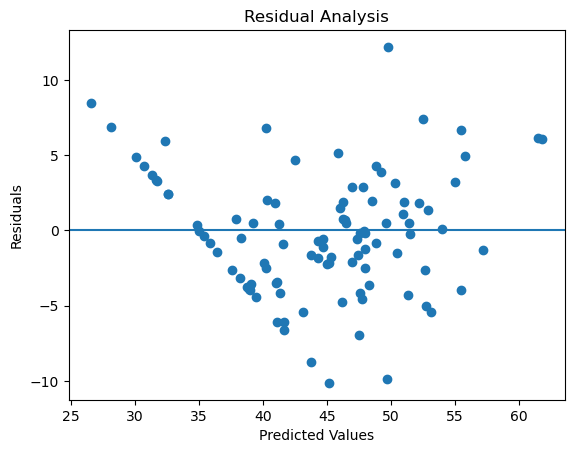

In [8]:
import matplotlib.pyplot as plt
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()